# 🧭 Support Vector Machine v klasifikaci – Ukázka implementace v Scikit-learn
### Kurz Data Science & Machine Learning | Coders Lab (09/2026)
> **Praktická ukázka ze slajdů kurzu (*Support vector machine - an example of implementation*):**
> 1. Vytvoření syntetického klasifikačního datasetu: `make_classification(n_samples=600, n_features=5, n_classes=2, random_state=42)`.
> 2. Rozdělení dat na trénovací (70 %) a testovací (30 %) sadu (`random_state=42`).
> 3. Import třídy `SVC` z modulu `sklearn.svm` a inicializace modelu bez hyperparametrů (výchozí RBF jádro).
> 4. Natrénování modelu a výpočet metrik **Accuracy (92.2 %)** a **Precision (92.4 %)** na testovací sadě.
> 5. Srovnání různých jádrových funkcí (`kernel="rbf"`, `"linear"`, `"poly"`, `"sigmoid"`) a rozbor jejich vlivu na metriky.
> 6. Vizuální zobrazení dělících oblastí a podpůrných vektorů.
> 7. Optimalizace hyperparametrů pomocí `GridSearchCV`.


## 1. Vytvoření syntetického datasetu a rozdělení dat (70/30)
Generujeme 600 vzorků s 5 příznaky a binárním cílem přesně podle slajdu 9.

In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# 1. Vytvoření klasifikačního datasetu
X, y = make_classification(
    n_samples=600,
    n_features=5,
    n_classes=2,
    random_state=42
)

# 2. Rozdělení na trénovací (70 %) a testovací (30 %) sadu
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Rozměry dat: X_train = {X_train.shape}, X_test = {X_test.shape}")
print(f"Počet vzorků ve třídách (Test): Třída 0 = {sum(y_test==0)}, Třída 1 = {sum(y_test==1)}")


Rozměry dat: X_train = (420, 5), X_test = (180, 5)
Počet vzorků ve třídách (Test): Třída 0 = 88, Třída 1 = 92


## 2. Výchozí model `SVC()` bez zadání hyperparametrů
Importujeme třídu `SVC` z modulu `sklearn.svm`. Výchozí konfigurace používá **RBF jádro** (`kernel='rbf'`), regularizaci $C=1{,}0$ a $\gamma=\text{'scale'}$. Natrénujeme model na trénovací sadě.

In [2]:
from sklearn.svm import SVC

# Inicializace výchozího modelu
clf_svc = SVC(random_state=42)

# Trénování modelu
clf_svc.fit(X_train, y_train)

print("Výchozí model SVC() byl úspěšně vytrénován.")
print(f"Použité jádro: {clf_svc.kernel}")
print(f"Celkový počet podpůrných vektorů: {len(clf_svc.support_)} (z {len(X_train)} trénovacích vzorků)")
print(f"Podpůrné vektory pro jednotlivé třídy: {clf_svc.n_support_}")


Výchozí model SVC() byl úspěšně vytrénován.
Použité jádro: rbf
Celkový počet podpůrných vektorů: 118 (z 420 trénovacích vzorků)
Podpůrné vektory pro jednotlivé třídy: [59 59]


## 3. Predikce na testovací sadě a výpočet metrik (Accuracy a Precision)
Vyhodnotíme predikce na testovacích datech přesně podle slajdů 11 a 12:
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}, \quad \text{Precision} = \frac{TP}{TP + FP}$$


In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Predikce na testovací sadě
y_pred = clf_svc.predict(X_test)

# Výpočet metrik
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy score:  {accuracy:.4f} ({accuracy*100:.1f} %)")
print(f"Precision score: {precision:.4f} ({precision*100:.1f} %)")
print(f"Recall score:    {recall:.4f} ({recall*100:.1f} %)")
print(f"F1-score:        {f1:.4f}")
print("\nMatice záměn:")
print(confusion_matrix(y_test, y_pred))


Accuracy score:  0.9222 (92.2 %)
Precision score: 0.9239 (92.4 %)
Recall score:    0.9239 (92.4 %)
F1-score:        0.9239

Matice záměn:
[[81  7]
 [ 7 85]]


## 4. Srovnání jádrových funkcí v cyklu (`rbf`, `linear`, `poly`, `sigmoid`)
Přesně podle kódu ze slajdu 12 napíšeme funkci `train_svm_classifier(kernel)` a otestujeme různá jádra.

In [4]:
def train_svm_classifier(kernel):
    clf = SVC(kernel=kernel, random_state=42)
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)

    return {
        "Jádro": kernel.upper(),
        "Accuracy (%)": round(acc * 100, 2),
        "Precision (%)": round(prec * 100, 2),
        "Recall (%)": round(rec * 100, 2),
        "Počet SV": len(clf.support_)
    }

results = []
for k in ["rbf", "linear", "poly", "sigmoid"]:
    res = train_svm_classifier(k)
    results.append(res)
    print(f"Accuracy score (kernel: {k}): {res['Accuracy (%)']:.1f} % | Precision: {res['Precision (%)']:.1f} %")

srovnani_jader = pd.DataFrame(results)
srovnani_jader


Accuracy score (kernel: rbf): 92.2 % | Precision: 92.4 %
Accuracy score (kernel: linear): 93.3 % | Precision: 94.4 %
Accuracy score (kernel: poly): 94.4 % | Precision: 95.6 %
Accuracy score (kernel: sigmoid): 89.4 % | Precision: 91.0 %


,Jádro,Accuracy (%),Precision (%),Recall (%),Počet SV
0,RBF,92.22,92.39,92.39,118
1,LINEAR,93.33,94.44,92.39,100
2,POLY,94.44,95.56,93.48,163
3,SIGMOID,89.44,91.01,88.04,99


## 5. Vizualizace dělících oblastí a podpůrných vektorů (2D projekce)
Protože dataset má 5 příznaků, nelze rozhodovací nadrovinu zobrazit celou v 5D. Vykreslíme 2D projekci na nejdůležitější příznaky (slajdy 13–14).

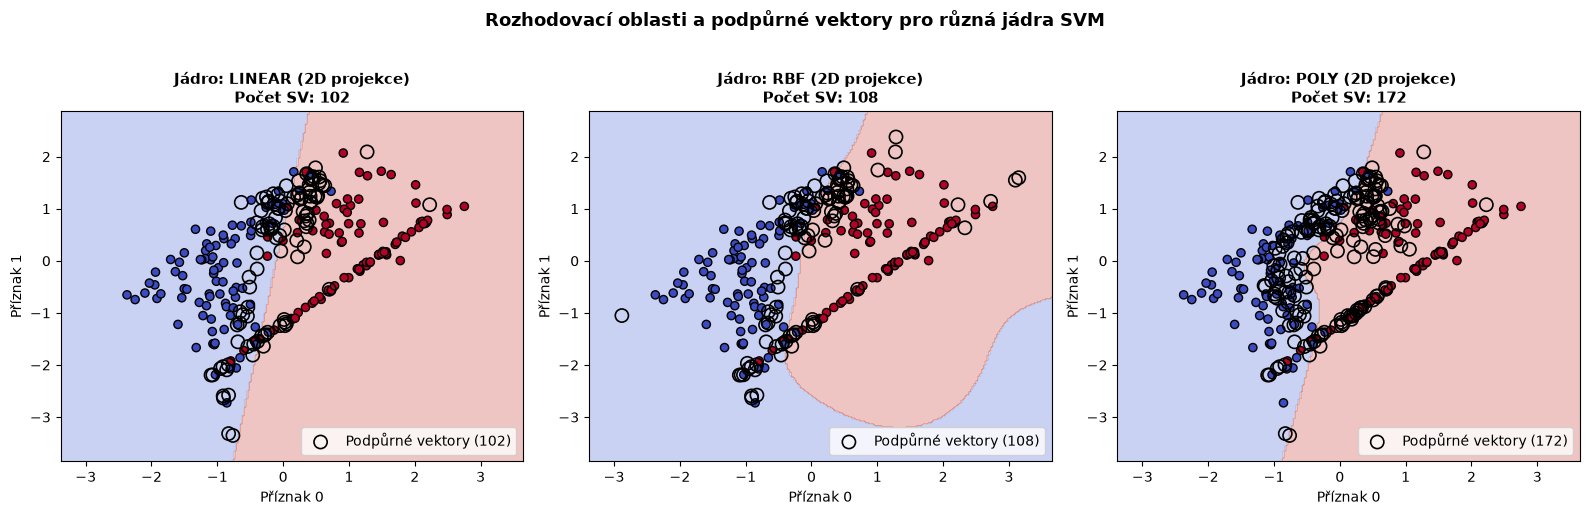

In [5]:
import matplotlib.pyplot as plt

X_train_2d = X_train[:, :2]
X_test_2d = X_test[:, :2]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))

for ax, k in zip(axes, ["linear", "rbf", "poly"]):
    m2d = SVC(kernel=k, random_state=42).fit(X_train_2d, y_train)
    Z = m2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, cmap="coolwarm", edgecolors="k", s=35)
    sv = m2d.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=90, facecolors="none", edgecolors="black", linewidths=1.2, label=f"Podpůrné vektory ({len(sv)})")

    ax.set_title(f"Jádro: {k.upper()} (2D projekce)\nPočet SV: {len(sv)}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Příznak 0")
    ax.set_ylabel("Příznak 1")
    ax.legend(loc="lower right")

plt.suptitle("Rozhodovací oblasti a podpůrné vektory pro různá jádra SVM", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 6. Optimalizace hyperparametrů pomocí `GridSearchCV`
Podle slajdu 14 prozkoumáme možnosti optimalizace hyperparametrů ($C$, $\gamma$, stupeň polynomu $d$).

In [6]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {"kernel": ["rbf"], "C": [0.1, 1.0, 10.0, 50.0], "gamma": ["scale", 0.01, 0.1, 1.0]},
    {"kernel": ["poly"], "C": [0.1, 1.0, 10.0], "degree": [2, 3, 4], "coef0": [0.0, 1.0]},
    {"kernel": ["linear"], "C": [0.01, 0.1, 1.0, 10.0]}
]

grid = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring="precision")
grid.fit(X_train, y_train)

best_svc = grid.best_estimator_
best_pred = best_svc.predict(X_test)

print(f"Nejlepší nalezené parametry: {grid.best_params_}")
print(f"Optimalizovaná Precision na testovací sadě: {precision_score(y_test, best_pred)*100:.2f} %")
print(f"Optimalizovaná Accuracy na testovací sadě:  {accuracy_score(y_test, best_pred)*100:.2f} %")
print(f"Počet podpůrných vektorů: {len(best_svc.support_)}")


Nejlepší nalezené parametry: {'C': 0.1, 'coef0': 1.0, 'degree': 3, 'kernel': 'poly'}
Optimalizovaná Precision na testovací sadě: 94.44 %
Optimalizovaná Accuracy na testovací sadě:  93.33 %
Počet podpůrných vektorů: 136
